In [1]:
import polymer_pl as pp
import scipy.constants as sc
import numpy as np

temperature = 700  # K
l = [2.548, 1.480,2.548, 1.480]
Angle = np.array([-15, -15, 15, 15])
rotation = np.array([0, 1, 0, 1])
labels = {
    1: {'loc': 'thiophene-thiophene.txt', 'color': 'b'},
}

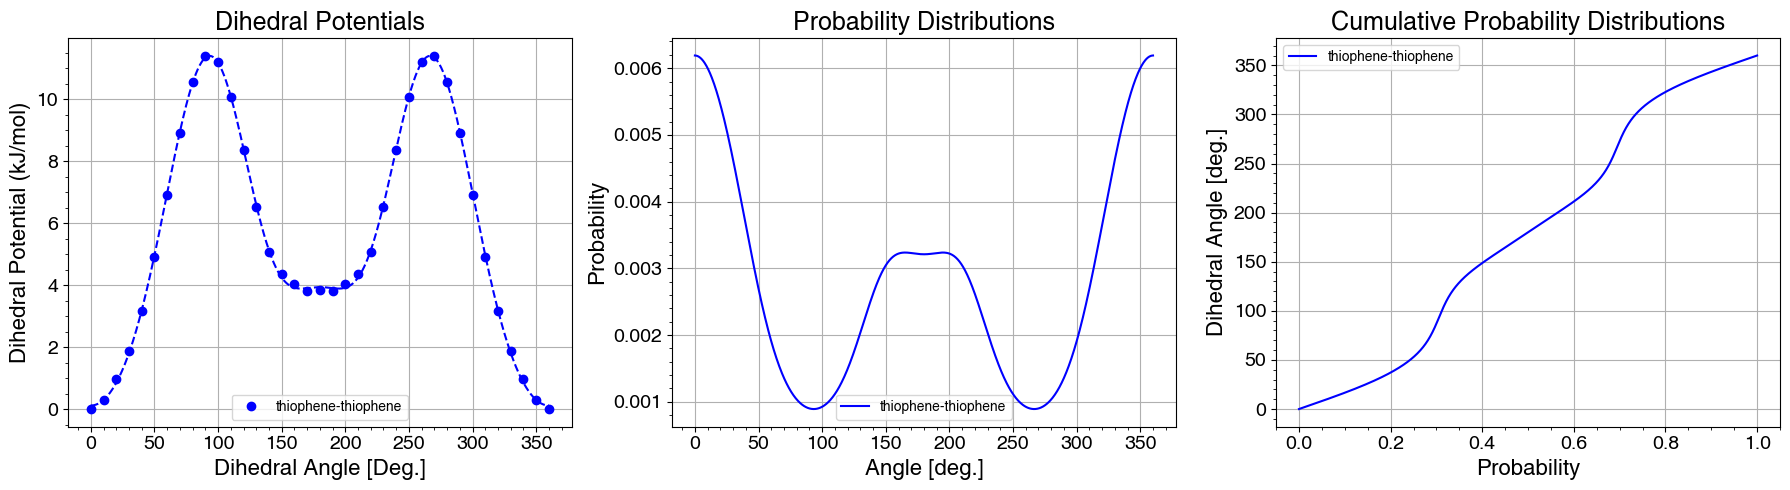

In [2]:
p3HT = pp.PolymerPersistence(l, Angle, temperature, rotation, labels, fittting_method='cosine', cosine_deg=5)
p3HT.plot_dihedral_potentials()

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.3s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    1.4s finished


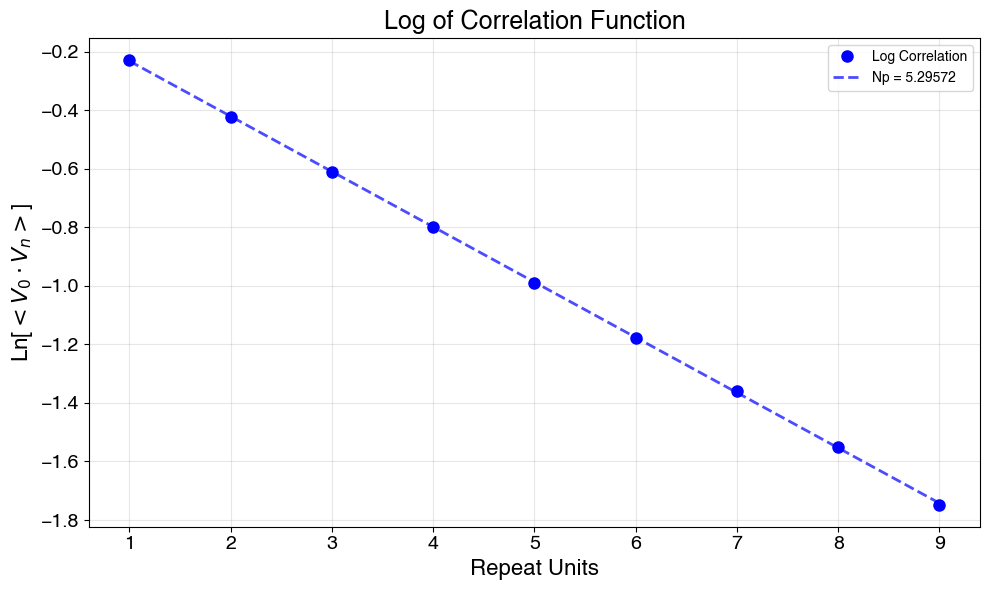

In [3]:
p3HT.plot_correlation_function(n_repeat_units=12,
                                n_samples=50000,
                                start_idx=1,
                                end_idx=12)  # Monte Carlo method
# note that a repeating unit contains 2 monomers, the final Np should be twice of shown number

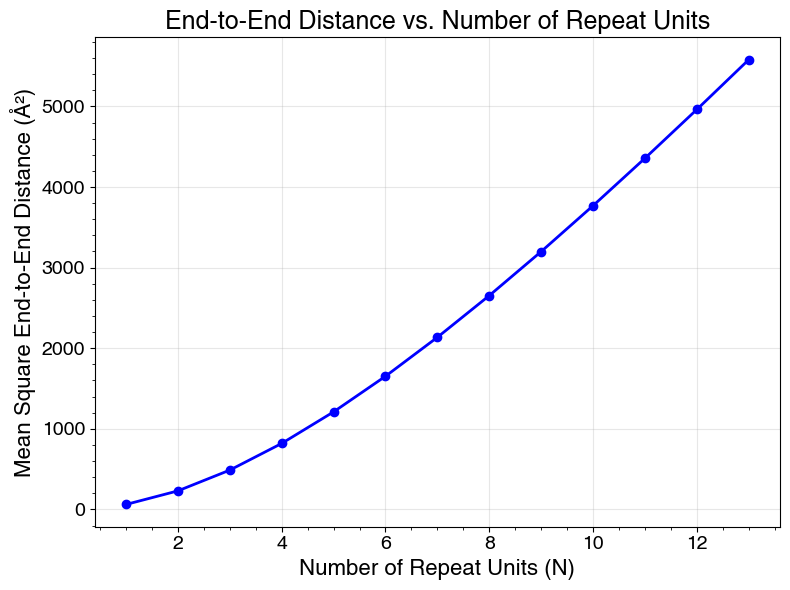

In [4]:
p3HT.plot_end_to_end_distance(N=12.5) # transfer matrix method

In [5]:
p3HT.report()  # transfer matrix method
# note that a repeating unit contains 2 monomers, the final Np should be twice of shown number

--- Persistence Length Calculation Report ---
Temperature: 700 K
Max Eigenvalue (lambda_max): 0.826519199080
Persistence Length (in repeat units): 5.248459
-------------------------------------------


In [6]:
from scipy.linalg import fractional_matrix_power

mat_dimer = p3HT.matrix
mat_monomer = fractional_matrix_power(mat_dimer, 1 / 2)
lambda_max =  float(np.max(np.abs(np.linalg.eigvals(mat_monomer))))
N_p = -1 / np.log(lambda_max)
print('Persistence Length (in repeat units)', N_p)
# original paper: 10.3279 (Monte Carlo)

Persistence Length (in repeat units) 10.496917095105625
